<a href="https://colab.research.google.com/github/keksenia/crowdsoursing_test/blob/main/crowdsourcing_test_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ краудсорсингового проекта

Проект: бинарная (фактически — трёхвариантная: `yes / no / not_working`) разметка релевантности сайтов. У исполнителей есть страницы заданий («ассайменты»), внутри — обычные и контрольные задания (ханипоты). У ханипотов известен правильный ответ — по ним и оцениваем качество.

В проекте — три задания: приведение данных к удобному виду, поиск проблемных контрольных заданий и расчёт метрик проекта.

> Данные: `test_ecom.tsv`

## Подготовка

In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# фирменная палитра для графиков
TEAL, AMBER, GREY = "#2f5d62", "#c97b3c", "#b6c2c4"

df = pd.read_csv("test_ecom.tsv", sep="\t")
print("страниц:", len(df), "| исполнителей:", df.worker_id.nunique())
print(df.assignment_status.value_counts())

страниц: 21437 | исполнителей: 2258
assignment_status
APPROVED    18579
EXPIRED      2815
SKIPPED        43
Name: count, dtype: int64


In [ ]:
# --- вспомогательные функции для разбора вложенного JSON ---

def get_url(task):
    """URL сайта, который оценивали в задании."""
    try:
        return task["input_values"]["input"]["view"]["data"]["region_markup"]["url"]
    except Exception:
        return None

def known_answer(task):
    """Правильный ответ для контрольного задания (ханипота). None — если обычное задание."""
    ks = task.get("known_solutions")
    if ks:
        try:
            return ks[0]["output_values"]["result"]
        except Exception:
            return None
    return None

## Задание 1. Привести данные к удобному формату

Исходные данные «широкие»: на одной строке — целая страница, а ответы и задания спрятаны в JSON-строках. Для анализа удобнее **длинный формат**: одна строка = одно задание. Параллельно:
- разворачиваем JSON-поля (`task_suite_raw_tasks` и `assignment_raw_solutions`) и сопоставляем ответ исполнителя с заданием по позиции в списке;
- переводим Unix-секунды в читаемые даты и считаем длительность работы над страницей;
- помечаем ханипоты и сразу считаем, верно ли исполнитель на них ответил.

In [ ]:
# разворачиваем каждую страницу в отдельные задания
rows = []
for r in df.itertuples(index=False):
    # обычные задания страницы
    try:
        tasks = json.loads(r.task_suite_raw_tasks)
    except Exception:
        tasks = []
    # ответы исполнителя (есть только у APPROVED; у EXPIRED/SKIPPED — пусто)
    try:
        sols = json.loads(r.assignment_raw_solutions) if isinstance(r.assignment_raw_solutions, str) else []
    except Exception:
        sols = []

    for i, task in enumerate(tasks):
        # ответ исполнителя на i-е задание сопоставляем по позиции
        ans = None
        if i < len(sols):
            try:
                ans = sols[i]["output_values"]["result"]
            except Exception:
                ans = None
        ka = known_answer(task)
        rows.append((
            r.assignment_assignment_id, r.worker_id, r.assignment_status,
            r.assignment_start_time, r.assignment_submit_time, r.assignment_skip_time,
            i, get_url(task), ka is not None, ka, ans
        ))

long = pd.DataFrame(rows, columns=[
    "assignment_id", "worker_id", "status",
    "start", "submit", "skip",
    "task_index", "url", "is_honeypot", "correct_answer", "worker_answer"])

# читаемое время + длительность страницы (сек)
for c in ["start", "submit", "skip"]:
    long[c + "_dt"] = pd.to_datetime(long[c], unit="s")
long["duration_sec"] = long["submit"] - long["start"]

# верность ответа считаем только для ханипотов, на которые ответили
long["is_correct"] = np.where(
    long["is_honeypot"] & long["worker_answer"].notna(),
    long["worker_answer"] == long["correct_answer"],
    np.nan)

print("заданий всего:", len(long))
print("ханипотов:", int(long.is_honeypot.sum()),
      "| из них с ответом:", int(long.is_correct.notna().sum()))
print("варианты ответов:", long.worker_answer.dropna().unique())

# показываем кусочек удобной таблицы
long[long.is_honeypot].head(6)[
    ["assignment_id", "worker_id", "url", "correct_answer", "worker_answer", "is_correct", "duration_sec"]]

заданий всего: 203963
ханипотов: 31063 | из них с ответом: 26551
варианты ответов: ['no' 'not_working' 'yes']


,assignment_id,worker_id,url,correct_answer,worker_answer,is_correct,duration_sec
3,1,6a9baea9-3f41-4368-b312-5d180dc3a1a6,https://toolhaus.ru,yes,no,0.0,132.0
8,1,6a9baea9-3f41-4368-b312-5d180dc3a1a6,https://skyheels.ru,no,yes,0.0,132.0
10,2,6a9baea9-3f41-4368-b312-5d180dc3a1a6,https://telfer-snab.ru,no,no,1.0,188.0
12,2,6a9baea9-3f41-4368-b312-5d180dc3a1a6,https://buket82.ru,no,no,1.0,188.0
26,3,6a9baea9-3f41-4368-b312-5d180dc3a1a6,https://flowers-bazar.ru,no,no,1.0,165.0
28,3,6a9baea9-3f41-4368-b312-5d180dc3a1a6,https://tuning-market.org,yes,no,0.0,165.0


**Вывод 1.** 21 437 страниц развёрнуты в **203 963 задания** в длинном формате, удобном для таблиц, графиков и расчётов. Ответы оказались не чисто бинарными — кроме `yes/no` есть `not_working` (сайт не открывается). Ответы заполнены только у страниц `APPROVED`; у `EXPIRED` (13%) и `SKIPPED` исполнитель ничего не отправил — это учитываем в метриках вовлечённости, но не в точности.

## Задание 2. Найти «сложные» и «неоднозначные» контрольные задания

Ханипот определяется своим URL. Группируем по URL и считаем долю верных ответов и распределение ответов. Сразу важная оговорка: **каждый ханипот показывают в среднем всего ~2 раза** (максимум 8), поэтому точную оценку по одному заданию строить нельзя — корректнее искать *кандидатов на ревью*:
- **сложные** — где исполнители массово ошибаются (низкая точность, вплоть до «все ошиблись»);
- **неоднозначные** — где ответы делятся примерно поровну, нет явного большинства.

In [ ]:
# агрегируем ханипоты по URL
hp = long[long.is_honeypot & long.worker_answer.notna()].copy()
hp["ok"] = (hp.worker_answer == hp.correct_answer).astype(int)

by_url = hp.groupby("url").agg(
    n=("ok", "size"),
    correct_ans=("correct_answer", "first"),
    n_correct=("ok", "sum"),
    accuracy=("ok", "mean"),
    share_yes=("worker_answer", lambda s: (s == "yes").mean()),
    share_no=("worker_answer", lambda s: (s == "no").mean()),
    share_nw=("worker_answer", lambda s: (s == "not_working").mean()),
).reset_index()
by_url["top_share"] = by_url[["share_yes", "share_no", "share_nw"]].max(axis=1)

# масштаб проблемы: смотрим ханипоты с >=2 показами
g2 = by_url[by_url.n >= 2]
print("ханипотов с >=2 показами:", len(g2))
print("  'все ошиблись' (accuracy = 0):  %.1f%% (%d шт)" % ((g2.accuracy == 0).mean()*100, (g2.accuracy == 0).sum()))
print("  'ровно пополам' (accuracy = 0.5): %.1f%% (%d шт)" % ((g2.accuracy == 0.5).mean()*100, (g2.accuracy == 0.5).sum()))
print("  проблемных (accuracy < 0.5):     %.1f%%" % ((g2.accuracy < 0.5).mean()*100))

ханипотов с >=2 показами: 9546
  'все ошиблись' (accuracy = 0):  16.2% (1543 шт)
  'ровно пополам' (accuracy = 0.5): 16.9% (1616 шт)
  проблемных (accuracy < 0.5):     18.9%


In [ ]:
# топ самых сложных ханипотов (берём >=4 показов, чтобы было чуть надёжнее)
g4 = by_url[by_url.n >= 4]
print("СЛОЖНЫЕ — низкая точность:")
display(g4.sort_values("accuracy").head(10)[["url", "n", "correct_ans", "n_correct", "accuracy"]])

print("НЕОДНОЗНАЧНЫЕ — нет явного большинства (top_share <= 0.6):")
display(g4[g4.top_share <= 0.6].sort_values("top_share").head(10)[
    ["url", "n", "correct_ans", "accuracy", "share_yes", "share_no", "share_nw"]].round(3))

СЛОЖНЫЕ — низкая точность:


,url,n,correct_ans,n_correct,accuracy
12512,https://спортфанат.рф,4,no,0,0.0
4088,https://grocenberg.store,6,no,0,0.0
4102,https://gruzzap32.ru,4,yes,0,0.0
3964,https://golod.store,4,no,0,0.0
4049,https://green-finger.ru,4,no,0,0.0
4029,https://grandmanor.ru,4,no,0,0.0
8610,https://rotorshop.ru,4,no,0,0.0
578,https://ambesonneorto.ru,4,no,0,0.0
622,https://andi-perm.ru,4,no,0,0.0
579,https://ambicioni.ru,4,no,0,0.0


НЕОДНОЗНАЧНЫЕ — нет явного большинства (top_share <= 0.6):


,url,n,correct_ans,accuracy,share_yes,share_no,share_nw
66,https://1pars.ru,4,no,0.5,0.50,0.5,0.00
134,https://425555.ru,4,yes,0.5,0.50,0.5,0.00
193,https://7953084.ru,4,no,0.5,0.50,0.5,0.00
227,https://aa-craft.ru,4,no,0.5,0.50,0.5,0.00
229,https://aa40.ru,4,no,0.5,0.25,0.5,0.25
295,https://advantix-pc.ru,4,no,0.5,0.50,0.5,0.00
296,https://aeg-com.ru,4,yes,0.5,0.50,0.5,0.00
362,https://airbeautyshop.ru,4,no,0.5,0.50,0.5,0.00
836,https://art-kormushka.com.ru,4,no,0.5,0.50,0.5,0.00
440,https://albinel.ru,4,no,0.5,0.50,0.5,0.00


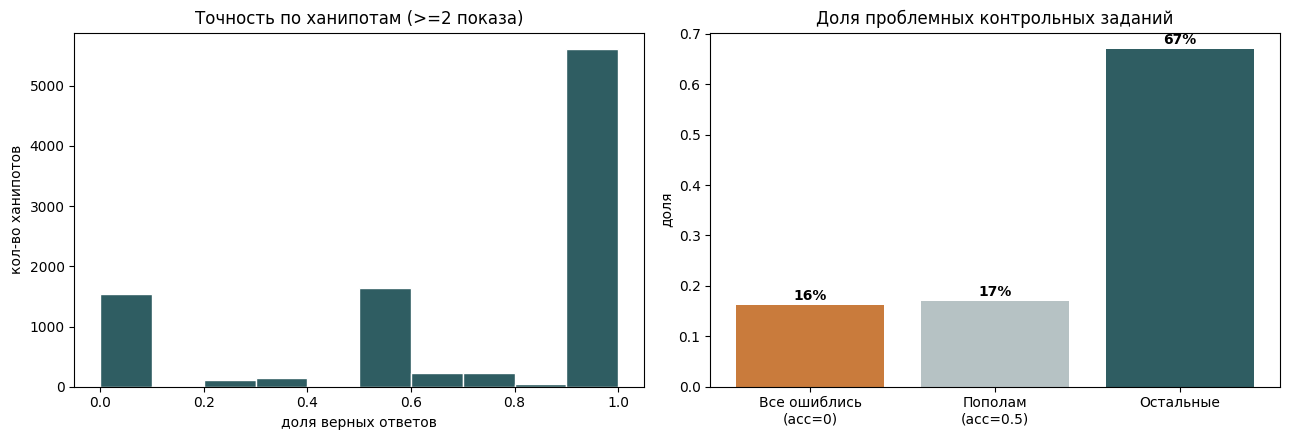

In [ ]:
# график: распределение точности по ханипотам + масштаб проблемных
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(g2.accuracy, bins=np.linspace(0, 1, 11), color=TEAL, edgecolor="white")
ax[0].set_title("Точность по ханипотам (>=2 показа)")
ax[0].set_xlabel("доля верных ответов"); ax[0].set_ylabel("кол-во ханипотов")

cats = ["Все ошиблись\n(acc=0)", "Пополам\n(acc=0.5)", "Остальные"]
vals = [(g2.accuracy == 0).mean(), (g2.accuracy == 0.5).mean(),
        1 - (g2.accuracy == 0).mean() - (g2.accuracy == 0.5).mean()]
ax[1].bar(cats, vals, color=[AMBER, GREY, TEAL])
ax[1].set_title("Доля проблемных контрольных заданий")
ax[1].set_ylabel("доля")
for i, v in enumerate(vals):
    ax[1].text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Вывод 2.** Среди ханипотов с ≥2 показами **16% — «все ошиблись», 17% — делятся ровно пополам**: вместе около трети контрольных заданий ведут себя проблемно. «Все ошиблись» — скорее признак неверного эталона или нечётко сформулированного задания (его стоит перепроверить вручную), а «пополам» — реально неоднозначные кейсы. Так как один ханипот показывают ~2 раза, эти списки — кандидаты на экспертное ревью, а не окончательный приговор; для надёжной оценки таким заданиям нужно больше показов.

## Задание 3. Метрики проекта

Считаю 5 метрик, которые вместе дают картину «качество — люди — эффективность»:

1. **Точность на ханипотах** — главная метрика *качества* проекта.
2. **Точность по исполнителям** — кого учить/убирать; управление качеством через людей.
3. **Доля EXPIRED** — *эффективность*: сколько выданной работы пропадает впустую.
4. **Скорость (сек/задание)** — санитарная метрика: ловит и перегруз, и «протыкивание» наугад.
5. **Баланс ответов** — нет ли перекоса/спама (например, исполнители жмут одну кнопку).

In [ ]:
ans = long[long.worker_answer.notna()]

# 1) КАЧЕСТВО: точность на ханипотах
quality = hp.ok.mean()

# 2) точность по исполнителям (>=10 ханипотов, чтобы оценка была осмысленной)
wq = hp.groupby("worker_id")["ok"].agg(n_hp="size", acc="mean")
wq10 = wq[wq.n_hp >= 10]

# 3) завершаемость страниц
status_share = df.assignment_status.value_counts(normalize=True)

# 4) скорость: секунд на задание по страницам APPROVED
n_tasks = long.groupby("assignment_id").size().rename("n_tasks")
appr = df[df.assignment_status == "APPROVED"].set_index("assignment_assignment_id")
speed = pd.DataFrame({"dur": appr.assignment_submit_time - appr.assignment_start_time}).join(n_tasks)
speed["sec_per_task"] = speed.dur / speed.n_tasks

# 5) баланс ответов
balance = ans.worker_answer.value_counts(normalize=True)

print("1) КАЧЕСТВО — точность на ханипотах: %.3f" % quality)
print("2) ЛЮДИ — исполнителей с >=10 ханипотами: %d | медианная точность: %.3f | минимум: %.3f | доля <0.5: %.1f%%"
      % (len(wq10), wq10.acc.median(), wq10.acc.min(), (wq10.acc < 0.5).mean()*100))
print("3) ЭФФЕКТИВНОСТЬ — EXPIRED: %.1f%% | APPROVED: %.1f%% | SKIPPED: %.1f%%"
      % (status_share.get("EXPIRED",0)*100, status_share.get("APPROVED",0)*100, status_share.get("SKIPPED",0)*100))
print("4) СКОРОСТЬ — медиана сек/задание: %.1f | подозрительно быстрых (<2 сек): %.2f%%"
      % (speed.sec_per_task.median(), (speed.sec_per_task < 2).mean()*100))
print("5) БАЛАНС ОТВЕТОВ — " + ", ".join(f"{k}: {v:.1%}" for k, v in balance.items()))

1) КАЧЕСТВО — точность на ханипотах: 0.719
2) ЛЮДИ — исполнителей с >=10 ханипотами: 1133 | медианная точность: 0.750 | минимум: 0.500 | доля <0.5: 0.0%
3) ЭФФЕКТИВНОСТЬ — EXPIRED: 13.1% | APPROVED: 86.7% | SKIPPED: 0.2%
4) СКОРОСТЬ — медиана сек/задание: 36.8 | подозрительно быстрых (<2 сек): 0.22%
5) БАЛАНС ОТВЕТОВ — yes: 53.6%, no: 41.3%, not_working: 5.1%


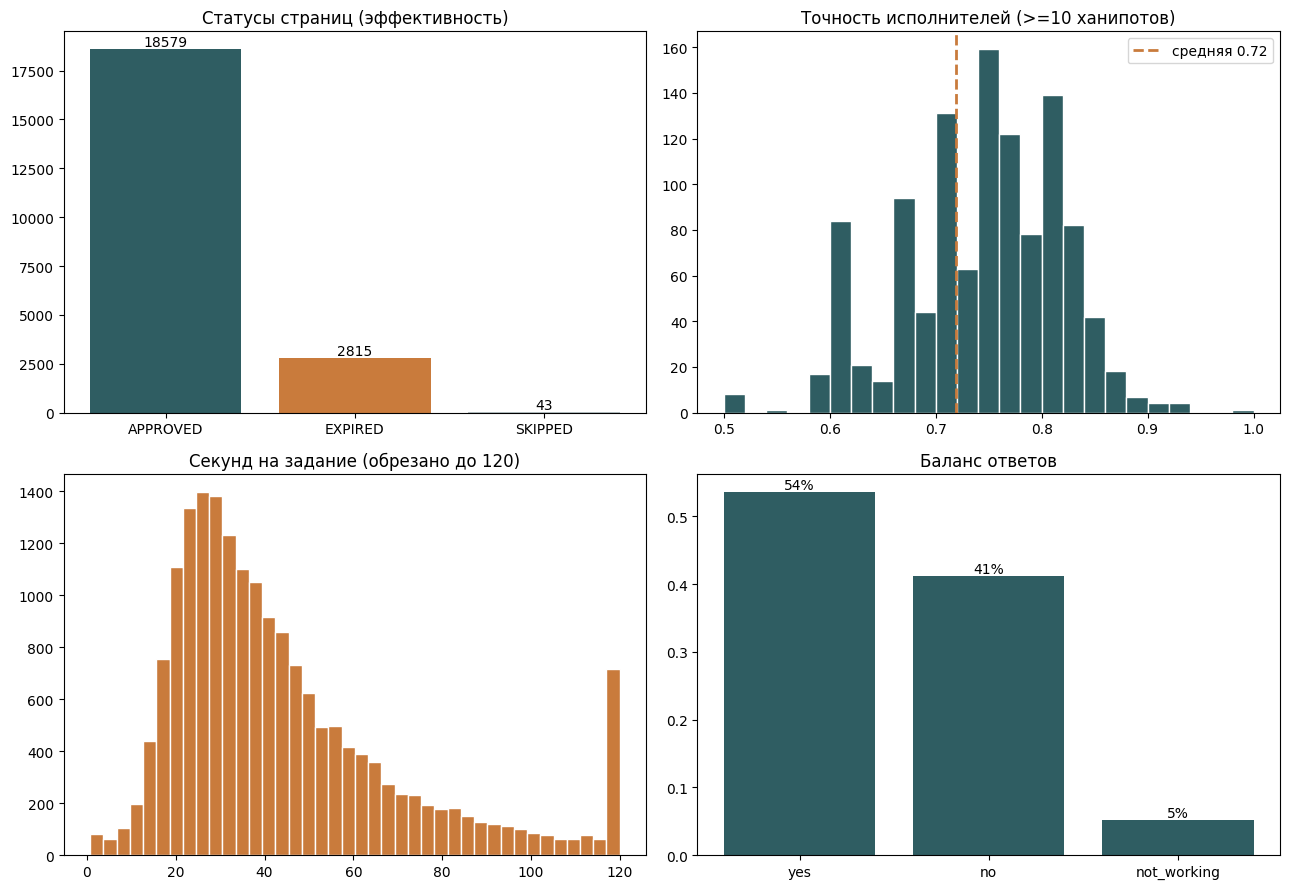

In [ ]:
# дашборд по метрикам
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

s = df.assignment_status.value_counts()
ax[0,0].bar(s.index, s.values, color=[TEAL, AMBER, GREY])
ax[0,0].set_title("Статусы страниц (эффективность)")
for i, v in enumerate(s.values): ax[0,0].text(i, v, f"{v}", ha="center", va="bottom")

ax[0,1].hist(wq10.acc, bins=25, color=TEAL, edgecolor="white")
ax[0,1].axvline(quality, color=AMBER, ls="--", lw=2, label=f"средняя {quality:.2f}")
ax[0,1].set_title("Точность исполнителей (>=10 ханипотов)"); ax[0,1].legend()

ax[1,0].hist(speed.sec_per_task.clip(upper=120), bins=40, color=AMBER, edgecolor="white")
ax[1,0].set_title("Секунд на задание (обрезано до 120)")

ax[1,1].bar(balance.index, balance.values, color=TEAL)
ax[1,1].set_title("Баланс ответов")
for i, v in enumerate(balance.values): ax[1,1].text(i, v, f"{v:.0%}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

**Вывод 3.** Качество проекта по ханипотам — **0.72**: примерно каждый третий-четвёртый контрольный ответ неверный, что много для бинарной задачи. При этом среди активных исполнителей (≥10 ханипотов) **никто не опускается ниже 0.5** — явных спамеров нет, и низкое качество идёт не от «вредителей», а от сложных/неоднозначных заданий (см. Задание 2) и, вероятно, отсева слабых выше по воронке. Главная зона потерь — **13% страниц EXPIRED** (работа выдана, но не сделана): это упущенная мощность, стоит смотреть на размер страниц и таймауты. Скорость здоровая (медиана ~37 сек/задание, «протыкивающих» <2 сек почти нет), а баланс ответов разумный (yes ~54%, no ~41%, not_working ~5%) — систематического перекоса нет.

## Итог

Данные приведены к удобному длинному формату (одно задание = одна строка). Ханипоты вскрыли структурную проблему: ~треть контрольных заданий либо проваливаются всеми, либо делят исполнителей пополам — их нужно отправить на ревью эталона. Общее качество 0.72 ограничено не людьми (явных спамеров нет), а самими заданиями; главный резерв эффективности — снизить 13% EXPIRED.

**Что я бы сделала дальше:** перепроверить эталоны у «все ошиблись» ханипотов, увеличить число показов на контрольное задание для надёжной оценки, и разобраться, почему истекает каждая седьмая страница.